In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

Dataset Shape: (200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [8]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df = df.drop_duplicates()
print("Duplicates removed successfully!")

Duplicates removed successfully!


In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

Categorical Columns:
Index(['Gender'], dtype='str')


C:\Users\prathibha\AppData\Local\Temp\ipykernel_8668\1032942568.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [12]:
# Select numerical columns except CustomerID
stats_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in stats_cols:
    print(f"\n--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())
    print("Skewness:", df[col].skew())


--- Age ---
Mean: 38.85
Median: 36.0
Mode: 32
Standard Deviation: 13.96900733155888
Skewness: 0.48556885096681657

--- Annual Income (k$) ---
Mean: 60.56
Median: 61.5
Mode: 54
Standard Deviation: 26.264721165271244
Skewness: 0.3218425498619055

--- Spending Score (1-100) ---
Mean: 50.2
Median: 50.0
Mode: 42
Standard Deviation: 25.823521668370173
Skewness: -0.047220201374263374


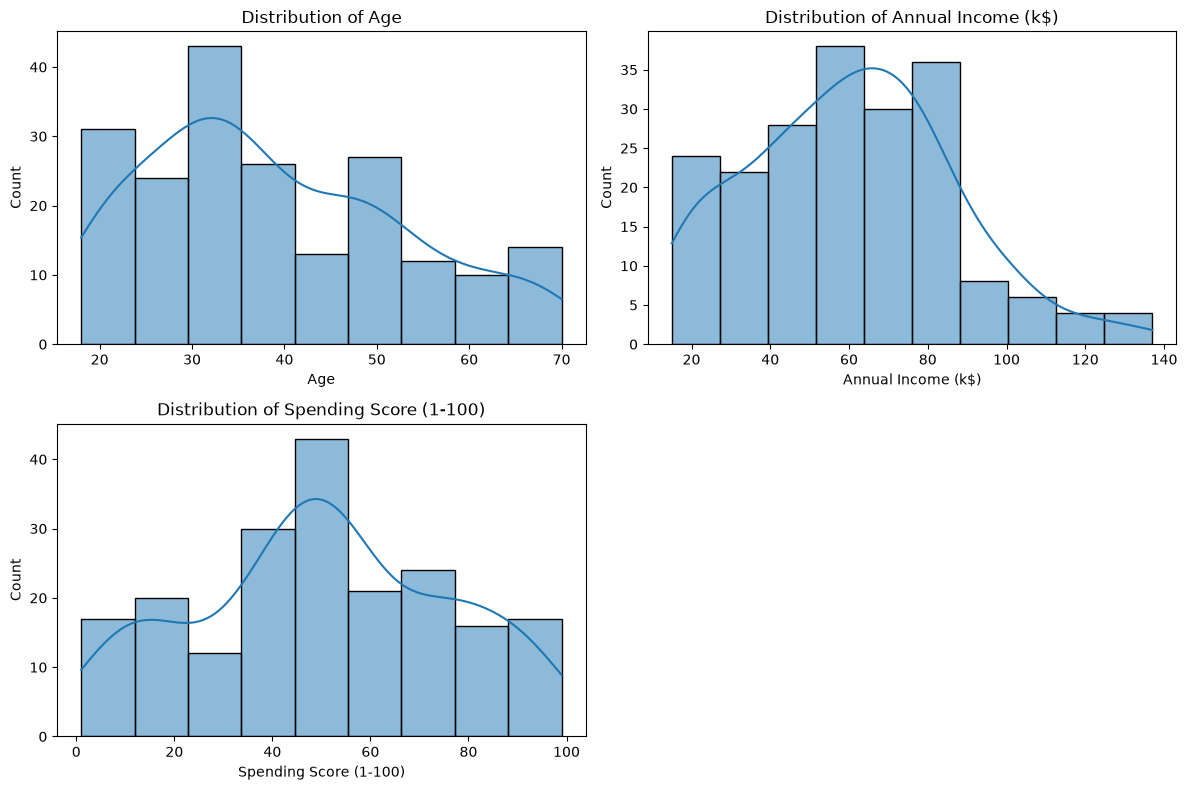

In [13]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(stats_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [14]:
for col in stats_cols:
    data = df[col].dropna()
    
    confidence = 0.95
    n = len(data)
    mean = data.mean()
    std_error = stats.sem(data)
    
    interval = stats.t.interval(
        confidence,
        n - 1,
        loc=mean,
        scale=std_error
    )
    
    print(f"{col} 95% Confidence Interval: {interval}")

Age 95% Confidence Interval: (np.float64(36.90218418511383), np.float64(40.79781581488617))
Annual Income (k$) 95% Confidence Interval: (np.float64(56.89768971230243), np.float64(64.22231028769757))
Spending Score (1-100) 95% Confidence Interval: (np.float64(46.59920985737689), np.float64(53.800790142623114))


In [15]:
male_income = df[df['Gender'] == 'Male']['Annual Income (k$)']
female_income = df[df['Gender'] == 'Female']['Annual Income (k$)']

t_stat, p_value = stats.ttest_ind(
    male_income,
    female_income,
    nan_policy='omit'
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("There is a significant difference in Annual Income between genders.")
else:
    print("There is no significant difference in Annual Income between genders.")

T-Statistic: 0.795022298602198
P-Value: 0.4275524939992786
There is no significant difference in Annual Income between genders.


In [16]:
# Create spending score categories
df['Spending_Category'] = pd.cut(
    df['Spending Score (1-100)'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

# Create contingency table
contingency_table = pd.crosstab(
    df['Gender'],
    df['Spending_Category']
)

print(contingency_table)

# Perform Chi-Square Test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

if p_value < 0.05:
    print("There is a significant association between Gender and Spending Category.")
else:
    print("There is no significant association between Gender and Spending Category.")

Spending_Category  Low  Medium  High
Gender                              
Female              34      46    32
Male                29      37    22

Chi-Square Statistic: 0.3496153237977684
P-Value: 0.8396184958669595
Degrees of Freedom: 2
There is no significant association between Gender and Spending Category.


In [17]:
print("STATISTICAL FINDINGS AND BUSINESS INSIGHTS")

print("\n1. Age Analysis:")
print("The dataset contains customers from different age groups,")
print("which helps identify potential target customers.")

print("\n2. Annual Income Analysis:")
print("Customers have varying income levels,")
print("which can be useful for personalized marketing strategies.")

print("\n3. Spending Score Analysis:")
print("Customers with high spending scores can be considered valuable customers.")
print("Low spending score customers may require targeted offers or promotions.")

print("\n4. Business Implication:")
print("Customer segmentation can help the business create personalized")
print("marketing strategies based on income and spending behavior.")

STATISTICAL FINDINGS AND BUSINESS INSIGHTS

1. Age Analysis:
The dataset contains customers from different age groups,
which helps identify potential target customers.

2. Annual Income Analysis:
Customers have varying income levels,
which can be useful for personalized marketing strategies.

3. Spending Score Analysis:
Customers with high spending scores can be considered valuable customers.
Low spending score customers may require targeted offers or promotions.

4. Business Implication:
Customer segmentation can help the business create personalized
marketing strategies based on income and spending behavior.


In [18]:
# Select features for customer segmentation
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Display first 5 rows
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print(X_scaled[:5])

Data scaled successfully!
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [20]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [30]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

C:\Users\prathibha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prathibha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prathibha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prathibha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memor

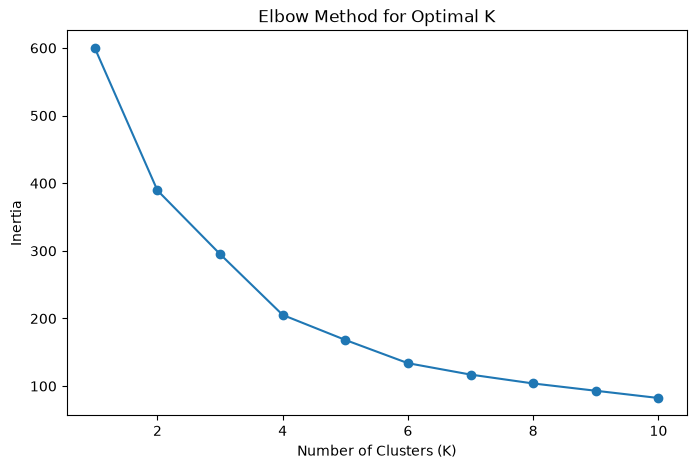

In [31]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())

   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   19                  15                      39        1
1   21                  15                      81        1
2   20                  16                       6        0
3   23                  16                      77        1
4   31                  17                      40        1


C:\Users\prathibha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


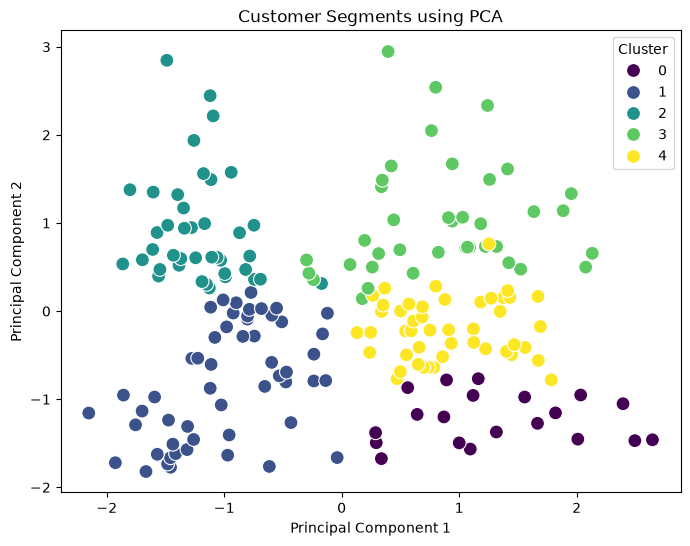

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Customer Segments using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [24]:
cluster_analysis = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print(cluster_analysis)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [25]:
print("CUSTOMER SEGMENT RECOMMENDATIONS")

print("\nCluster 0: Analyze customer income and spending behavior.")
print("Recommendation: Use personalized marketing campaigns.")

print("\nCluster 1: Customers with potential for increased spending.")
print("Recommendation: Provide special offers and discounts.")

print("\nCluster 2: High-value customers.")
print("Recommendation: Provide loyalty rewards and premium services.")

print("\nCluster 3: Moderate-value customers.")
print("Recommendation: Use targeted promotions.")

print("\nCluster 4: Low-spending customers.")
print("Recommendation: Encourage purchases through discounts and campaigns.")

CUSTOMER SEGMENT RECOMMENDATIONS

Cluster 0: Analyze customer income and spending behavior.
Recommendation: Use personalized marketing campaigns.

Cluster 1: Customers with potential for increased spending.
Recommendation: Provide special offers and discounts.

Cluster 2: High-value customers.
Recommendation: Provide loyalty rewards and premium services.

Cluster 3: Moderate-value customers.
Recommendation: Use targeted promotions.

Cluster 4: Low-spending customers.
Recommendation: Encourage purchases through discounts and campaigns.


In [26]:
from sklearn.model_selection import train_test_split

X_model = df[['Age', 'Annual Income (k$)']]
y_model = df['Spending Score (1-100)']

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 2)
Testing data shape: (40, 2)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.019631778132180422
MAE: 18.228973408316733
RMSE: 21.98992546040307


In [28]:
feature_importance = pd.DataFrame({
    'Feature': X_model.columns,
    'Coefficient': model.coef_
})

feature_importance['Absolute Importance'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Absolute Importance',
    ascending=False
)

print("FEATURE IMPORTANCE:")
print(feature_importance)

FEATURE IMPORTANCE:
              Feature  Coefficient  Absolute Importance
0                 Age    -0.589292             0.589292
1  Annual Income (k$)     0.052358             0.052358


In [29]:
print("\nFINAL SUMMARY")

print("1. Statistical analysis was performed using descriptive statistics.")
print("2. Confidence intervals and hypothesis tests were conducted.")
print("3. Customer segmentation was performed using K-Means clustering.")
print("4. PCA was used to visualize customer clusters in 2D.")
print("5. A Linear Regression model was built to predict Spending Score.")
print("6. Model performance was evaluated using R², MAE, and RMSE.")
print("7. The analysis provides useful insights for customer targeting and marketing strategies.")


FINAL SUMMARY
1. Statistical analysis was performed using descriptive statistics.
2. Confidence intervals and hypothesis tests were conducted.
3. Customer segmentation was performed using K-Means clustering.
4. PCA was used to visualize customer clusters in 2D.
5. A Linear Regression model was built to predict Spending Score.
6. Model performance was evaluated using R², MAE, and RMSE.
7. The analysis provides useful insights for customer targeting and marketing strategies.
